In [68]:
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from scipy.sparse import load_npz, hstack
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import nltk
import numpy as np
import optuna
import pandas as pd
import time

Se carga dataset.

In [69]:
X_train = load_npz('datasets/X_train.npz')
X_test = load_npz('datasets/X_test.npz')
y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

Se agregan los tres features más significativos recomendados en la bibliografía útiles para este tipo de algoritmos; se sugieren muchos más, pero también se sugiere que se use la menor cantidad de features extra para alcanzar la mejor eficiencia del modelo.

In [70]:
X_extra_train = pd.read_csv('datasets/X_extra_train.csv')
X_extra_test = pd.read_csv('datasets/X_extra_test.csv')

### Cantidad de verbos imperativos
Cuenta la presencia de verbos directivos o de mando en el correo electrónico. En la bibliografía, los verbos específicos considerados son "click", "verify",
"submit", "download" y "update").

In [71]:
IMPERATIVE_VERBS = ['click', 'verify', 'submit', 'download', 'update']

def get_imperative_verb_count(text):
    return sum(text.lower().count(verb) for verb in IMPERATIVE_VERBS)

X_extra_train['imperative_verbs_count'] = X_extra_train['remainder__Email Text Raw'].apply(get_imperative_verb_count)
X_extra_test['imperative_verbs_count'] = X_extra_test['remainder__Email Text Raw'].apply(get_imperative_verb_count)

### Complejidad en oraciones
Considera el número de conectores por oración. Se divide por el número total de oraciones, lo que permite medir cuántas oraciones subordinadas pueden aparecer en todo el texto.

In [72]:
LINKING_WORDS = ['and', 'but', 'or', 'because']

nltk.data.path.append('nltk_data')
nltk.download('punkt_tab', 'nltk_data')

def get_clause_density(text):
    sentence_count = len(sent_tokenize(text))
    if sentence_count == 0:
        return 0.0
    total_conjunctions = sum(text.lower().count(word) for word in LINKING_WORDS)
    complexity_ratio = total_conjunctions / sentence_count
    return complexity_ratio / sentence_count

X_extra_train['clause_density'] = X_extra_train['remainder__Email Text Raw'].apply(get_clause_density)
X_extra_test['clause_density'] = X_extra_test['remainder__Email Text Raw'].apply(get_clause_density)

[nltk_data] Downloading package punkt_tab to nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### Densidad de pronombres
Divide el número total de pronombres entre el número total de palabras.

In [73]:
TARGET_PRONOUNS = ['i', 'you', 'he', 'she', 'it', 'we', 'they']

def get_pronoun_density(text):
    tokens = word_tokenize(text.lower())
    total_words = len(tokens)
    if total_words == 0:
        return 0.0
    pronoun_count = sum(1 for word in tokens if word in TARGET_PRONOUNS)
    return pronoun_count / total_words

X_extra_train['pronoun_density'] = X_extra_train['remainder__Email Text Raw'].apply(get_pronoun_density)
X_extra_test['pronoun_density'] = X_extra_test['remainder__Email Text Raw'].apply(get_pronoun_density)

KNN requiere valores estandarizados.

In [74]:
extra_cols = ['imperative_verbs_count', 'clause_density', 'pronoun_density']

X_train = hstack([X_train, X_extra_train[extra_cols].values])
X_test = hstack([X_test, X_extra_test[extra_cols].values])

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Se inicializa KNN con _k = 5_ y se prueba.

In [75]:
knn_model = KNeighborsClassifier(n_neighbors=5)

start_train_time = time.time()
knn_model.fit(X_train_scaled, y_train)
end_train_time = time.time()

train_duration = end_train_time - start_train_time

start_predict_duration = time.time()
y_pred = knn_model.predict(X_test_scaled)
end_predict_duration = time.time()

predict_duration = end_predict_duration - start_predict_duration

#### Métricas

Se evalúa.

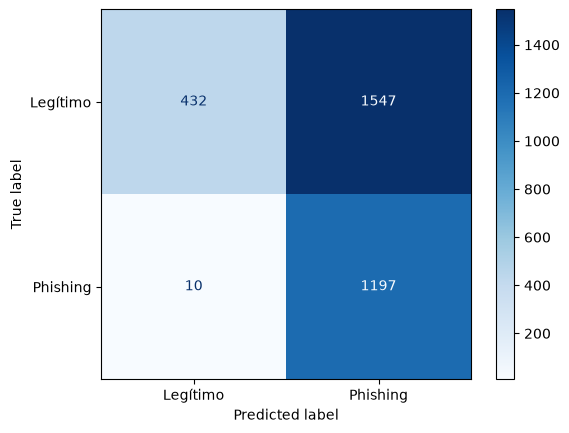

In [76]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [77]:
cm_knn = confusion_matrix(y_test, y_pred)
P = cm_knn[1, :].sum()
N = cm_knn[0, :].sum()
TP = cm_knn[1, 1]
TN = cm_knn[0, 0]

TPR_knn = TP / P
TNR_knn = TN / N
balanced_accuracy_knn = (TPR_knn + TNR_knn) / 2

precision_knn = precision_score(y_test, y_pred, zero_division=0)
recall_knn = recall_score(y_test, y_pred, zero_division=0)
f1_knn = f1_score(y_test, y_pred, zero_division=0)

print(f"Exactitud balanceada:  {balanced_accuracy_knn:.4f}")
print(f"Precisión:             {precision_knn:.4f}")
print(f"Sensibilidad (Recall): {TPR_knn:.4f}")
print(f"F1-score:              {f1_knn:.4f}")
print(f"Especificidad:         {TNR_knn:.4f}")
print(f"Recuperación (Recall): {recall_knn:.4f}")

Exactitud balanceada:  0.6050
Precisión:             0.4362
Sensibilidad (Recall): 0.9917
F1-score:              0.6059
Especificidad:         0.2183
Recuperación (Recall): 0.9917


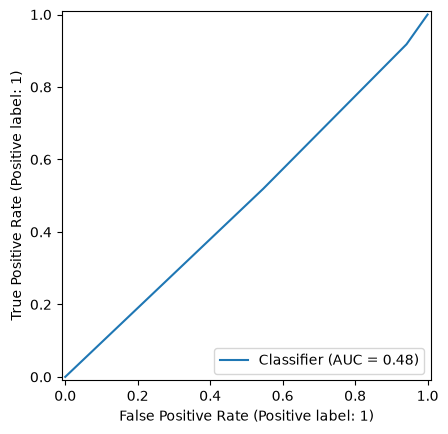

In [78]:
y_scores = knn_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

Está adivinando. Es un desastre.

## Optimización de parámetros

Se define la función objetivo y se prepara el estudio.

In [79]:
def objective(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 1, 50)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    metric = trial.suggest_categorical("metric", ["euclidean", "manhattan", "cosine"])

    model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric)

    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='f1', n_jobs=-1)
    return score.mean()

def champion_callback(study, frozen_trial):
    winner = study.user_attrs.get("winner", None)

    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value)
            improvement_percent *= 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} "
                f"with {improvement_percent: .4f}% improvement"
            )
        else:
            print(f"Initial trial {frozen_trial.number} achieved value: " 
            f"{frozen_trial.value}")

optuna.logging.set_verbosity(optuna.logging.ERROR)

Se ejecutan 100 trials.

In [80]:
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.HyperbandPruner)
study.optimize(objective, n_trials=100, callbacks=[champion_callback], n_jobs=-1)

Initial trial 0 achieved value: 0.9015619747752562
Trial 6 achieved value: 0.9017457465643585 with  0.0204% improvement
Trial 9 achieved value: 0.9176623553018609 with  1.7345% improvement
Trial 34 achieved value: 0.917893735782994 with  0.0252% improvement


In [81]:
best_params = study.best_params
best_params

{'n_neighbors': 50, 'weights': 'distance', 'metric': 'cosine'}

Se entrena el modelo con los parámetros resultantes de la optimización.

In [82]:
optimized_knn_model = KNeighborsClassifier(**best_params)

start_train_time = time.time()
optimized_knn_model.fit(X_train_scaled, y_train)
end_train_time = time.time()

train_duration = end_train_time - start_train_time

start_predict_duration = time.time()
y_pred = optimized_knn_model.predict(X_test_scaled)
end_predict_duration = time.time()

predict_duration = end_predict_duration - start_predict_duration

#### Métricas

Se evalúa.

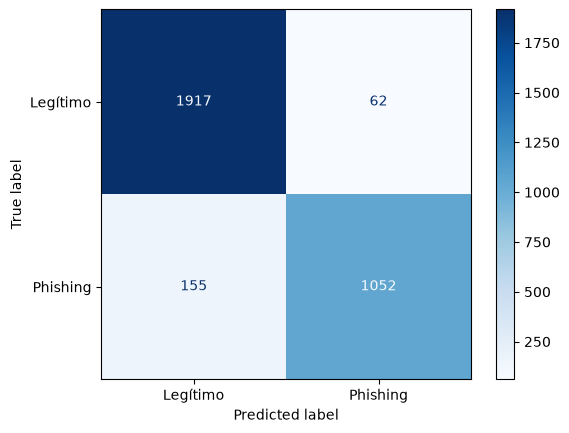

In [83]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [84]:
cm_optimized_knn = confusion_matrix(y_test, y_pred)
P_opt = cm_optimized_knn[1, :].sum()
N_opt = cm_optimized_knn[0, :].sum()
TP_opt = cm_optimized_knn[1, 1]
TN_opt = cm_optimized_knn[0, 0]

TPR_knn_opt = TP_opt / P_opt
TNR_knn_opt = TN_opt / N_opt
balanced_accuracy_knn_opt = (TPR_knn_opt + TNR_knn_opt) / 2

precision_knn_opt = precision_score(y_test, y_pred, zero_division=0)
recall_knn_opt = recall_score(y_test, y_pred, zero_division=0)
f1_knn_opt = f1_score(y_test, y_pred, zero_division=0)

print("                       Antes   Después")
print(f"Exactitud balanceada:  {balanced_accuracy_knn:.4f}  {balanced_accuracy_knn_opt:.4f}")
print(f"Precisión:             {precision_knn:.4f}  {precision_knn_opt:.4f}")
print(f"Sensibilidad (Recall): {TPR_knn:.4f}  {TPR_knn_opt:.4f}")
print(f"F1-score:              {f1_knn:.4f}  {f1_knn_opt:.4f}")
print(f"Especificidad:         {TNR_knn:.4f}  {TNR_knn_opt:.4f}")
print(f"Recuperación (Recall): {recall_knn:.4f}  {recall_knn_opt:.4f}")

                       Antes   Después
Exactitud balanceada:  0.6050  0.9201
Precisión:             0.4362  0.9443
Sensibilidad (Recall): 0.9917  0.8716
F1-score:              0.6059  0.9065
Especificidad:         0.2183  0.9687
Recuperación (Recall): 0.9917  0.8716


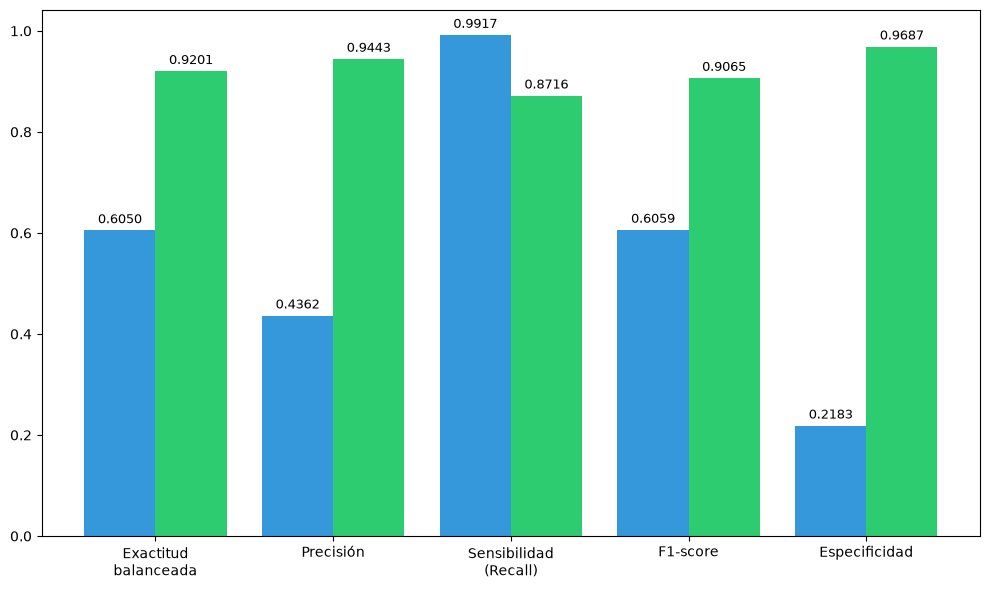

In [85]:
metrics_names = [
    'Exactitud\nbalanceada', 
    'Precisión', 
    'Sensibilidad\n(Recall)', 
    'F1-score', 
    'Especificidad'
]

before_vals = [
    balanced_accuracy_knn, 
    precision_knn, 
    TPR_knn, 
    f1_knn, 
    TNR_knn
]

after_vals = [
    balanced_accuracy_knn_opt, 
    precision_knn_opt, 
    TPR_knn_opt, 
    f1_knn_opt, 
    TNR_knn_opt
]

x = np.arange(5)

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - 0.2, before_vals, 0.4, color='#3498db')
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)
rects2 = ax.bar(x + 0.2, after_vals, 0.4, color='#2ecc71')
for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=10)

plt.tight_layout()
plt.show()


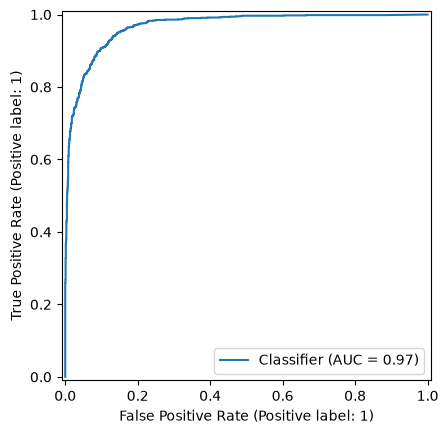

In [86]:
y_scores = optimized_knn_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

Funcionó.